<a href="https://colab.research.google.com/github/Mohan102945/mohan102945.github.io/blob/main/NN_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
X,y = fetch_openml('mnist_784',return_X_y=True)

In [3]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
type(X)

pandas.core.frame.DataFrame

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB


In [6]:
X = X / 255.0

In [7]:
X = X.values

In [8]:
y = y.values

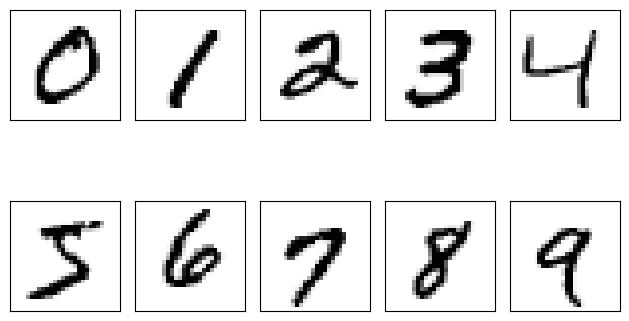

In [9]:
from matplotlib import pyplot as plt
fig,ax = plt.subplots(nrows = 2,ncols = 5,sharex = True,sharey=True)
ax = ax.flatten()
for i in range(10):
  img = X[y.astype(int)==i][0].reshape(28,28)
  ax[i].imshow(img,cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

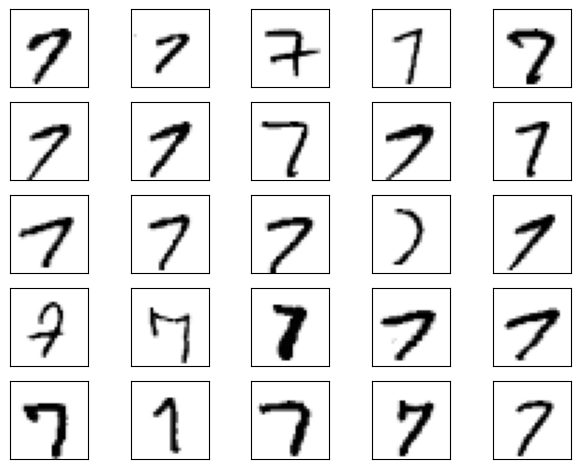

In [10]:
fig,ax = plt.subplots(nrows = 5,ncols = 5,sharex = True,sharey=True)
ax = ax.flatten()
for i in range(25):
  img = X[y.astype(int)==7][i].reshape(28,28)
  ax[i].imshow(img,cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_temp,x_test,y_temp,y_test = train_test_split(X,y,test_size = 10000,random_state=123,stratify = y)
x_train,x_val,y_train,y_val = train_test_split(x_temp,y_temp,test_size = 5000,random_state=123,stratify=y_temp)

In [13]:
import numpy as np
def int_to_one_hot(y, num_classes):
  ary = np.zeros((y.shape[0], num_classes))
  for i,val in enumerate(y):
    ary[i,int(val)] = 1
  return ary

In [14]:
def sigmoid(z):
  return 1./(1.+np.exp(-z))

In [15]:
class NeuralNetMLP:
  def __init__(self,num_classes,num_features,num_hidden,random_seed=123):
    self.num_classes = num_classes
    self.num_features = num_features
    self.num_hidden = num_hidden

    rng = np.random.RandomState(random_seed)

    self.weight_h = rng.normal(loc = 0.0,scale = 0.1,size = (self.num_hidden,self.num_features))
    self.bias_h = np.zeros(self.num_hidden)
    self.weight_o = rng.normal(loc = 0.0,scale = 0.1,size = (self.num_classes,self.num_hidden))
    self.bias_o = np.zeros(self.num_classes)

  def forward(self,x):
    z_h = np.dot(x,self.weight_h.T)+self.bias_h
    a_h = sigmoid(z_h)
    z_o = np.dot(a_h,self.weight_o.T)+self.bias_o
    a_o = sigmoid(z_o)
    return a_h,a_o

  def backward(self, x, a_h, a_o, y):

    y_onehot = int_to_one_hot(y, self.num_classes)

    # input/output dim: [n_examples, n_classes]
    d_loss_d_a_out = 2. * (a_o - y_onehot) / y.shape[0]

    # input/output dim: [n_examples, n_classes]
    d_a_out_d_z_out = a_o * (1. - a_o) # sigmoid derivative

    # output dim: [n_examples, n_classes]
    delta_out = d_loss_d_a_out * d_a_out_d_z_out

    # gradient for output weights

    # [n_examples, n_hidden]
    d_z_out_dw_out = a_h

    # input dim: [n_classes, n_examples]
    #           dot [n_examples, n_hidden]
    # output dim: [n_classes, n_hidden]
    d_loss_dw_out = np.dot(delta_out.T, d_z_out_dw_out)
    d_loss_db_out = np.sum(delta_out, axis=0)

    # [n_classes, n_hidden]
    d_z_out_a_h = self.weight_o

    # output dim: [n_examples, n_hidden]
    d_loss_a_h = np.dot(delta_out, d_z_out_a_h)

    # [n_examples, n_hidden]
    d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative

    # [n_examples, n_features]
    d_zh_dwh = x

    # output dim: [n_hidden, n_features]
    d_loss_d_w_h = np.dot((d_loss_a_h * d_a_h__d_z_h).T,d_zh_dwh)
    d_loss_d_b_h = np.sum((d_loss_a_h * d_a_h__d_z_h), axis=0)

    return (d_loss_dw_out, d_loss_db_out,
    d_loss_d_w_h, d_loss_d_b_h)

In [16]:
model = NeuralNetMLP(num_classes = 10,num_features=28*28,num_hidden = 50)

In [17]:
# To generate a random subset from the dataset


def minibatch_generator(x,y,minibatch_size):
    indices = np.arange(y.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0,y.shape[0]-minibatch_size+1,minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield x[batch_idx],y[batch_idx]

In [18]:
def mse(target,probas,num_labels):
  onehot_target = int_to_one_hot(target, num_labels)
  return np.mean(onehot_target-probas)**2

In [19]:
def accuracy(y,predicted):
  return np.mean(predicted == y.astype(int))

In [20]:
_,probas = model.forward(x_val)

In [21]:
mse = mse(y_val,probas,10)

In [22]:
mse

np.float64(0.15130941767199949)

In [23]:
predicted_labels = np.argmax(probas,axis = 1)
acc = accuracy(y_val,predicted_labels)
acc

np.float64(0.092)

In [24]:
def compute_mse_and_acc(nnet,X,y,minibatch_size,num_labels=10):
  mse,correct_pred,num_examples = 0.,0.,0.
  minibatch = minibatch_generator(X,y,minibatch_size = minibatch_size)
  for i,(features,targets) in enumerate(minibatch):
    _,probas = nnet.forward(features)
    predicted_labels = np.argmax(probas,axis = 1)
    onehot_target = int_to_one_hot(targets, num_labels)
    loss = np.mean((onehot_target - probas) ** 2)
    correct_pred += (predicted_labels == targets.astype(int)).sum()
    num_examples += targets.shape[0]
    mse += loss

  mse = mse/i
  acc = correct_pred/num_examples
  return mse, acc

In [25]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,learning_rate=0.1):
  epoch_loss = []
  epoch_train_acc = []
  epoch_valid_acc = []

  for e in range(num_epochs):
    # iterate over minibatches
    minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size=100)
    for x_train_mini, y_train_mini in minibatch_gen:
      #### Compute outputs ####
      a_h, a_o = model.forward(x_train_mini)

      #### Compute gradients ####
      d_loss_d_w_out, d_loss_d_b_out, \
      d_loss_d_w_h, d_loss_d_b_h = \
      model.backward(x_train_mini, a_h, a_o,
      y_train_mini)

      #### Update weights ####
      model.weight_h -= learning_rate * d_loss_d_w_h
      model.bias_h -= learning_rate * d_loss_d_b_h
      model.weight_o -= learning_rate * d_loss_d_w_out
      model.bias_o -= learning_rate * d_loss_d_b_out

    #### Epoch Logging ####
    train_mse, train_acc = compute_mse_and_acc(
    model, X_train, y_train, minibatch_size=100)

    valid_mse, valid_acc = compute_mse_and_acc(
    model, X_valid, y_valid, minibatch_size=100)

    train_acc, valid_acc = train_acc*100, valid_acc*100
    epoch_train_acc.append(train_acc)
    epoch_valid_acc.append(valid_acc)
    epoch_loss.append(train_mse)
    print(f'Epoch: {e+1:03d}/{num_epochs:03d}'
          f'| Train MSE: {train_mse:.2f} '
          f'| Train Acc: {train_acc:.2f}% '
          f'| Valid Acc: {valid_acc:.2f}%')

  return epoch_loss, epoch_train_acc, epoch_valid_acc

In [26]:
epoch_loss, epoch_train_acc, epoch_valid_acc = train(model, x_train, y_train, x_val, y_val,num_epochs=50, learning_rate=0.1)

Epoch: 001/050| Train MSE: 0.07 | Train Acc: 65.19% | Valid Acc: 65.44%
Epoch: 002/050| Train MSE: 0.04 | Train Acc: 79.55% | Valid Acc: 79.14%
Epoch: 003/050| Train MSE: 0.03 | Train Acc: 84.43% | Valid Acc: 83.72%
Epoch: 004/050| Train MSE: 0.03 | Train Acc: 86.88% | Valid Acc: 86.10%
Epoch: 005/050| Train MSE: 0.02 | Train Acc: 88.03% | Valid Acc: 87.84%
Epoch: 006/050| Train MSE: 0.02 | Train Acc: 88.78% | Valid Acc: 88.70%
Epoch: 007/050| Train MSE: 0.02 | Train Acc: 89.38% | Valid Acc: 89.20%
Epoch: 008/050| Train MSE: 0.02 | Train Acc: 89.82% | Valid Acc: 89.88%
Epoch: 009/050| Train MSE: 0.02 | Train Acc: 90.14% | Valid Acc: 90.22%
Epoch: 010/050| Train MSE: 0.02 | Train Acc: 90.44% | Valid Acc: 90.64%
Epoch: 011/050| Train MSE: 0.02 | Train Acc: 90.64% | Valid Acc: 90.74%
Epoch: 012/050| Train MSE: 0.02 | Train Acc: 90.95% | Valid Acc: 91.04%
Epoch: 013/050| Train MSE: 0.02 | Train Acc: 91.20% | Valid Acc: 91.22%
Epoch: 014/050| Train MSE: 0.02 | Train Acc: 91.47% | Valid Acc:

Text(0, 0.5, 'Mean Squared Error')

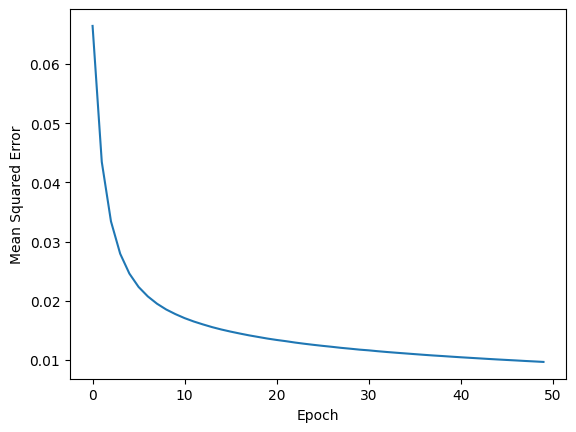

In [27]:
plt.plot(range(len(epoch_loss)),epoch_loss)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')

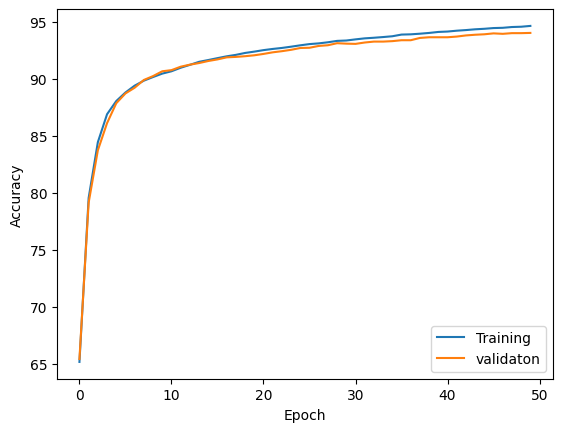

In [28]:
plt.plot(range(len(epoch_loss)),epoch_train_acc,label = 'Training')
plt.plot(range(len(epoch_loss)),epoch_valid_acc,label = 'validaton')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc = 'lower right')
plt.show()

In [29]:
test_mse,test_acc = compute_mse_and_acc(model,x_test,y_test,minibatch_size = 100)

In [30]:
print(f'test mse {test_mse:.2f}\n'
      f'test accuracy {test_acc*100:.2f}%')

test mse 0.01
test accuracy 93.96%
